In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("Modified_SQL_Dataset.csv") 
df.head()

,Query,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [5]:
df['Label'].value_counts()

Label
0    19537
1    11382
Name: count, dtype: int64

In [7]:
df = df.dropna()
X = df['Query']
y = df['Label']

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9529430789133247
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      3893
           1       0.98      0.89      0.93      2291

    accuracy                           0.95      6184
   macro avg       0.96      0.94      0.95      6184
weighted avg       0.95      0.95      0.95      6184



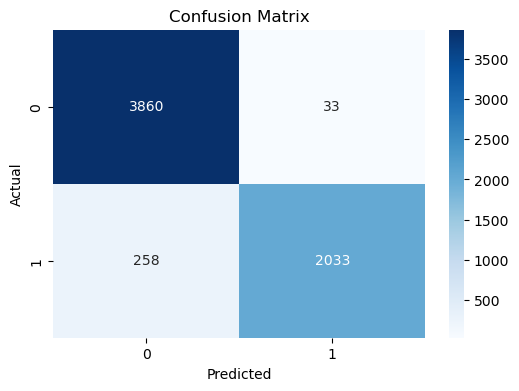

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8101552393272963
              precision    recall  f1-score   support

           0       1.00      0.70      0.82      3893
           1       0.66      1.00      0.80      2291

    accuracy                           0.81      6184
   macro avg       0.83      0.85      0.81      6184
weighted avg       0.87      0.81      0.81      6184



In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
sample = ["' OR 1=1 --"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print(prediction)

[1]
